<img src="title_image.jpg" alt="My Image" width="1000" height ="100"/>

# Customer Segmentation using RFM

### PROBLEM:
#### Marketing campaigns are currently sent to all customers uniformly, leading to low efficiency and poor engagement.

### GOAL:
##### The goal of this analysis is to segment customers based on their purchasing history.
##### It will help us understand the distinct segments and tailor marketing strategies to these segments.
##### I will use RFM (Recency,Frequency and Monetary) model for this project

#### 1. Clean and prepare data

In [2]:
# 1. IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [6]:
# 2. DATA LOADING & CLEANING

customers_df = pd.read_csv("C:/Users/lenovo/Downloads/marketing_campaign.csv", delimiter=';')
customers_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [17]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   object 
 3   Marital_Status       2216 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   object 
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   int64 

In [18]:
customers_df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [16]:
# 3. CHECK FOR NULL & DUPLICATES
(customers_df.isna().sum()/customers_df.shape[0] *100).round(1)

# there are 1% null values in INCOME column, the data is large and we could still do customer segmentation after removing these nulls.
customers_df = customers_df.dropna()

customers_df.duplicated().sum() # there are no duplicate customers data 

np.int64(0)

In [20]:
customers_df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

### 2. Engineer behavioral features

In [32]:
# FEATURE ENGINEERING

# Total spending across categories
customers_df['Total_Spent'] = (customers_df['MntWines'] + customers_df['MntFruits'] + customers_df['MntMeatProducts'] 
                               + customers_df['MntFishProducts'] + customers_df['MntSweetProducts'] + customers_df['MntGoldProds'])

# Total purchases
customers_df['Quantity'] = (customers_df['NumDealsPurchases'] + customers_df['NumWebPurchases'] 
                            + customers_df['NumCatalogPurchases']+ customers_df['NumStorePurchases'])

# Income segmentation
customers_df['Income_Segment'] = pd.qcut(customers_df["Income"], q=3, labels=["Low", "Medium", "High"])

### 3. EXPLORATORY DATA ANALYSIS

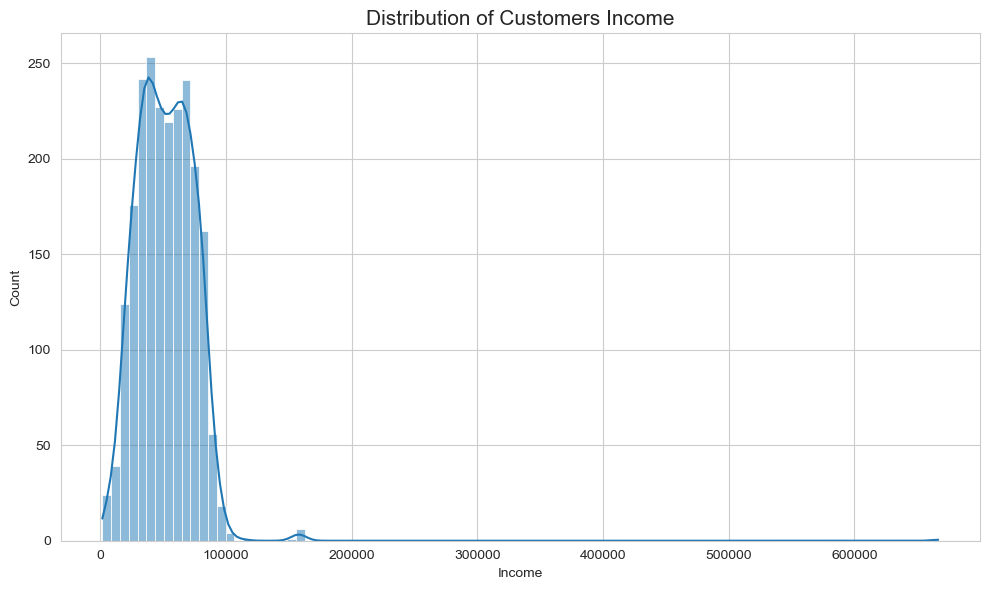

In [21]:
# Customer Behavior & Characteristics :

# Let's first see the distribution of customer's income:
plt.figure(figsize=(10,6))
sns.histplot(data=customers_df,x ='Income',kde=True)
plt.title("Distribution of Customers Income",fontsize = 15)

# Adjust the layout to make sure everything is centered and fits nicely
plt.tight_layout()

In [ ]:
# The average income of costumer base is around 50k (USD)

In [25]:
# let's see the marital status of our customer base:

marital_status_df = customers_df.groupby('Marital_Status')['ID'].count().reset_index(name='Count').sort_values(by=['Count'],ascending=False)
marital_status_df

,Marital_Status,Count
3,Married,857
5,Together,573
4,Single,471
2,Divorced,232
6,Widow,76
1,Alone,3
0,Absurd,2
7,YOLO,2


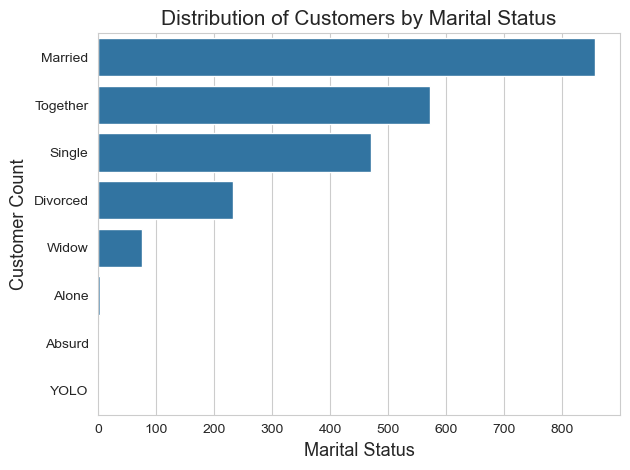

In [27]:
# now visualize customers marital status:
sns.barplot(marital_status_df,y ='Marital_Status',x = 'Count')
plt.title("Distribution of Customers by Marital Status",fontsize = 15)
plt.xlabel("Marital Status",fontsize=13)
plt.ylabel("Customer Count",fontsize=13)
plt.tight_layout()

In [35]:
# Purchasing patterns across different Income levels:
income_spending_df = (customers_df.groupby('Income_Segment')['Total_Spent'].mean().reset_index()).round(1)
income_spending_df

C:\Users\lenovo\AppData\Local\Temp\ipykernel_9120\2306962305.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_spending_df = (customers_df.groupby('Income_Segment')['Total_Spent'].mean().reset_index()).round(1)


,Income_Segment,Total_Spent
0,Low,94.9
1,Medium,458.9
2,High,1267.3


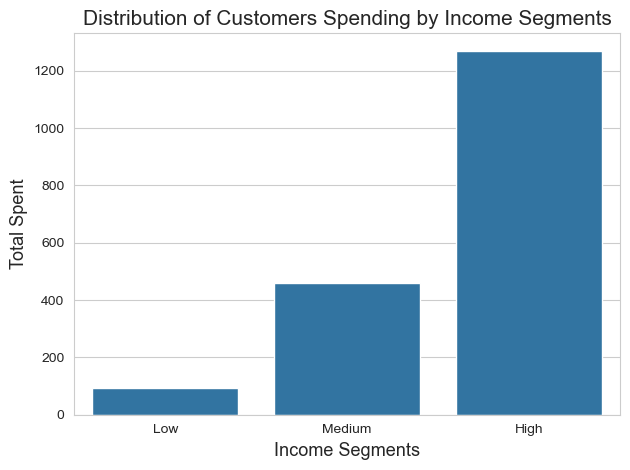

In [37]:
# let's plot customers income and see how much they spent:
sns.barplot(income_spending_df,x ='Income_Segment',y ='Total_Spent')
plt.title("Distribution of Customers Spending by Income Segments",fontsize = 15)
plt.xlabel("Income Segments",fontsize=13)
plt.ylabel("Total Spent",fontsize=13)
plt.tight_layout()

""" 
Customers with High Income on average spends little over 1200(USD), 
Medium Income spends on average around 450(USD),
and customers with Low Income spends on average around 100(USD).
"""

In [39]:
customers_df.groupby('Income_Segment')[[ 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
       'AcceptedCmp5']].sum().reset_index()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_9120\3623070143.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customers_df.groupby('Income_Segment')[[ 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',


,Income_Segment,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
0,Low,1,0,63,3,0
1,Medium,11,11,48,62,2
2,High,130,19,52,99,160


In [41]:
# Customers Responses to various Marketing Campaigns by Income Segment
campaign_response_df = customers_df.groupby('Income_Segment')[[ 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
       'AcceptedCmp5']].sum().reset_index()
campaign_response_df.columns = ['Income_Segment','Campaign1','Campaign2','Campaign3','Campaign4','Campaign5']
campaign_response_df.head()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_9120\3703385861.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_response_df = customers_df.groupby('Income_Segment')[[ 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',


,Income_Segment,Campaign1,Campaign2,Campaign3,Campaign4,Campaign5
0,Low,1,0,63,3,0
1,Medium,11,11,48,62,2
2,High,130,19,52,99,160


In [42]:
campaign_response_df = pd.melt(campaign_response_df,id_vars=['Income_Segment'],var_name ='Campaigns',value_name='Responses')
campaign_response_df

,Income_Segment,Campaigns,Responses
0,Low,Campaign1,1
1,Medium,Campaign1,11
2,High,Campaign1,130
3,Low,Campaign2,0
4,Medium,Campaign2,11
5,High,Campaign2,19
6,Low,Campaign3,63
7,Medium,Campaign3,48
8,High,Campaign3,52
9,Low,Campaign4,3


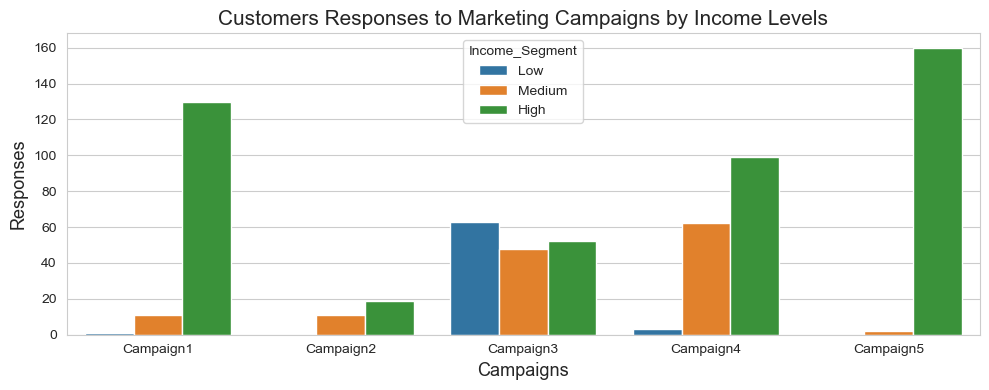

In [47]:
# let's now plot the data:
plt.figure(figsize=(10,4))
sns.barplot(campaign_response_df,x ='Campaigns',y = 'Responses', hue ='Income_Segment')
plt.title('Customers Responses to Marketing Campaigns by Income Levels',fontsize = 15)
plt.xlabel("Campaigns",fontsize=13)
plt.ylabel("Responses",fontsize=13)
plt.tight_layout()

""" 
High Income customers are responding more to campaign 5 and campaign 1. 
Low Income level responded well to Campaign 3,
while Campaign 3 and 4 worked well for Medium Income Customers.
"""

### 4. RFM ANALYSIS


In [ ]:
# Calculates Recency, Frequency, Monetary values

In [49]:
# Days since last purchase 
recency = customers_df.groupby("ID")["Recency"].min().reset_index()
recency.head()

,ID,Recency
0,0,66
1,1,0
2,9,86
3,13,57
4,17,81


In [59]:
# How often do customers purchase?
frequency = customers_df.groupby("ID")["Quantity"].sum().reset_index(name='Frequency')
frequency.head()

,ID,Frequency
0,0,17
1,1,18
2,9,11
3,13,6
4,17,28


In [60]:
# How much customers spent?
monetary = customers_df.groupby("ID")["Total_Spent"].sum().reset_index(name='Monetary')
monetary.head()

,ID,Monetary
0,0,1198
1,1,577
2,9,120
3,13,32
4,17,1028


In [61]:
# Merge recency, frequency and montary value:
rfm = recency.merge(frequency, on='ID').merge(monetary, on='ID')
rfm.head()

,ID,Recency,Frequency,Monetary
0,0,66,17,1198
1,1,0,18,577
2,9,86,11,120
3,13,57,6,32
4,17,81,28,1028


In [63]:
# Let's create scores for each one:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5]).astype(int)

rfm.head()

,ID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,0,66,17,1198,2,3,5
1,1,0,18,577,5,4,3
2,9,86,11,120,1,2,2
3,13,57,6,32,3,1,1
4,17,81,28,1028,1,5,4


In [91]:
# Define the segments:
def assign_segments(row):
    
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return "Champions"
    
    elif row['R_score'] == 1 and row['F_score'] >= 3:
        return "At Risk"
    
    elif row['F_score'] >= 4:
        return "Loyal Customers"
    
    elif row['M_score'] >= 4:
        return "Big Spenders"
    
    elif row['R_score'] >= 3:
        return "Potential Customers"
    
    else:
        return "Hibernating"
        
rfm['Segment'] = rfm.apply(assign_segments, axis=1)
rfm.head()

,ID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
0,0,66,17,1198,2,3,5,Big Spenders
1,1,0,18,577,5,4,3,Champions
2,9,86,11,120,1,2,2,Hibernating
3,13,57,6,32,3,1,1,Potential Customers
4,17,81,28,1028,1,5,4,At Risk


In [92]:
# Now check number of customers in each segment and their spending:
segment_summary = (rfm.groupby('Segment').agg(Customer_Count =('ID','count'),
                                          Average_Monetary = ('Monetary','mean')).reset_index()).round(1)
segment_summary

,Segment,Customer_Count,Average_Monetary
0,At Risk,259,972.8
1,Big Spenders,147,1265.1
2,Champions,346,1087.1
3,Hibernating,392,99.6
4,Loyal Customers,362,1104.0
5,Potential Customers,710,130.3


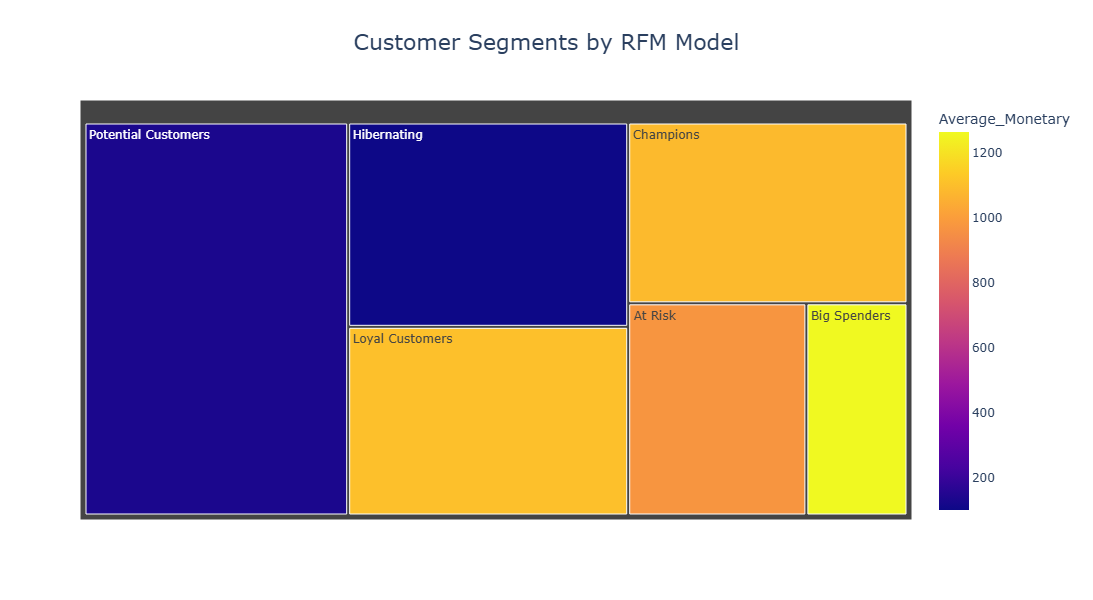

In [93]:
import plotly.express as px

fig = px.treemap(segment_summary,path =['Segment'],values ='Customer_Count',color ='Average_Monetary',
                 color_continuous_scale='Plasma',
                title ='Customer Segments by RFM Model')

# customize the plot:
fig.update_layout(title_font_size=22,
    title_x=0.5,
    width=800,  # Set figure width
    height=600  # Set figure height
)

fig.update_traces(
    hovertemplate ='<b>%{label}</b><br>' +
                    'Customer_Count : %{value:.0f}<br>' +
                    'Average_Monetary : $%{color:.0f}<br>' +
                    '<extra></extra>')
fig.show()

### 5. Engagement & Revenue

####  1. Which customer segment show the highest level of engagement with our marketing efforts?

In [96]:
engagement_df = pd.merge(rfm[['ID','Segment']],customers_df[['ID','AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
       'AcceptedCmp5']],on = 'ID',how = 'outer')
engagement_df.head()

,ID,Segment,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
0,0,Big Spenders,0,0,0,0,0
1,1,Champions,0,1,0,0,0
2,9,Hibernating,0,0,0,0,0
3,13,Potential Customers,0,0,0,0,0
4,17,At Risk,0,0,0,0,0


In [97]:
# delete the ID column since we do not need it anymore:
engagement_df = engagement_df.drop('ID',axis=1)

In [99]:
# group by customer segments and count the campaign responses:
campaign_response_by_segment = engagement_df.groupby('Segment')[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
       'AcceptedCmp5']].sum().reset_index()
campaign_response_by_segment.columns = ['Segment','Campaign1','Campaign2','Campaign3','Campaign4','Campaign5']
campaign_response_by_segment.head()

,Segment,Campaign1,Campaign2,Campaign3,Campaign4,Campaign5
0,At Risk,24,6,23,31,31
1,Big Spenders,22,5,6,24,31
2,Champions,51,7,38,44,53
3,Hibernating,0,0,19,8,0
4,Loyal Customers,42,10,23,47,47


In [100]:
# Putting the dataframe into long format:
campaign_response_by_segment = pd.melt(campaign_response_by_segment,id_vars= ['Segment'],var_name= 'Campaigns', value_name= 'Response')
campaign_response_by_segment.head()

,Segment,Campaigns,Response
0,At Risk,Campaign1,24
1,Big Spenders,Campaign1,22
2,Champions,Campaign1,51
3,Hibernating,Campaign1,0
4,Loyal Customers,Campaign1,42


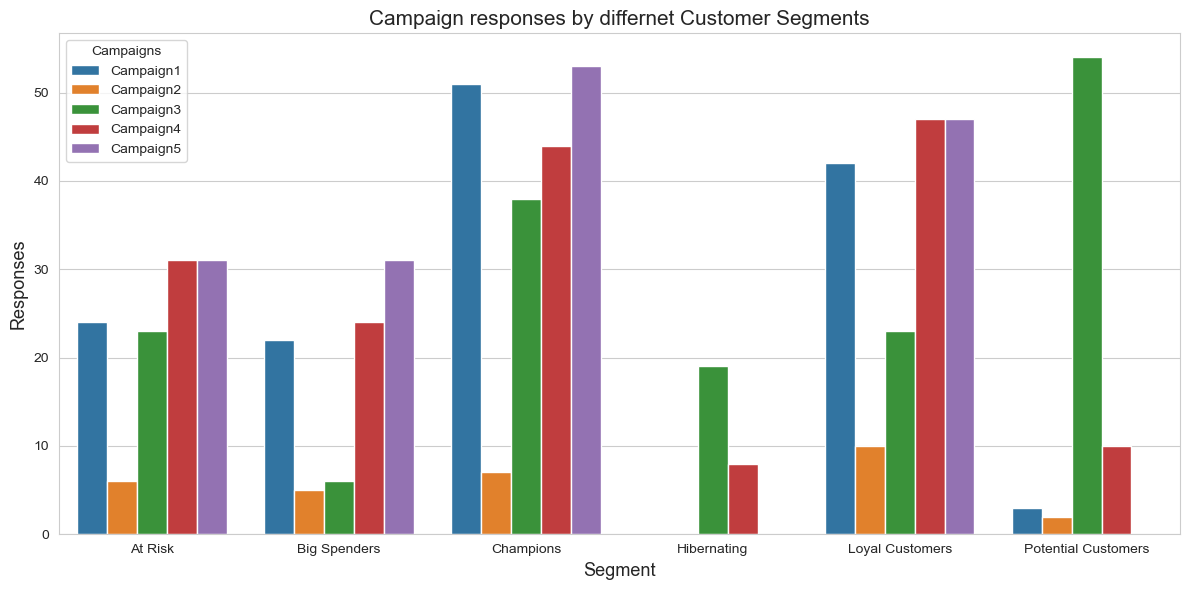

In [104]:
plt.figure(figsize= (12,6))
sns.barplot(campaign_response_by_segment,x ='Segment',y='Response',hue ='Campaigns')
plt.title("Campaign responses by differnet Customer Segments",fontsize = 15)
plt.xlabel("Segment",fontsize=13)
plt.ylabel("Responses",fontsize=13)
plt.tight_layout()

1. 'Champions' segment shows the highest engagement with campaign 1 and 5.
2. Campaign 2 shows least engagement across all customer segments.
3. 'Potential customers' segment has highest engagement with Campaign 3.

### 2. Which customer segment has most customers?

In [109]:
customers_per_segment = rfm.groupby('Segment')['ID'].nunique().reset_index(name='Customer Count').sort_values('Customer Count',ascending =False)
customers_per_segment

,Segment,Customer Count
5,Potential Customers,710
3,Hibernating,392
4,Loyal Customers,362
2,Champions,346
0,At Risk,259
1,Big Spenders,147


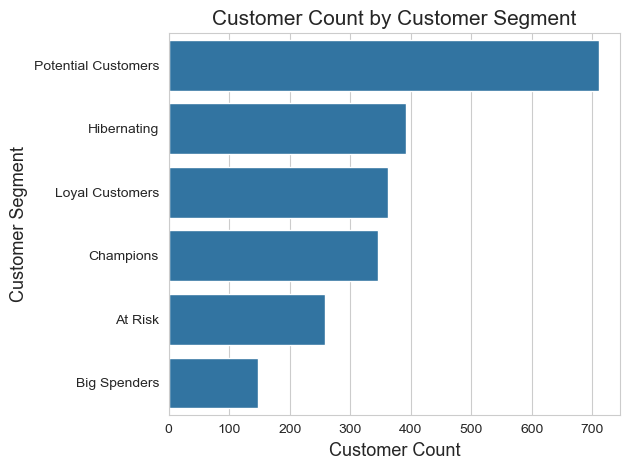

In [110]:
sns.barplot(customers_per_segment,y= 'Segment',x ='Customer Count',orient='h')
plt.title("Customer Count by Customer Segment",fontsize = 15)
plt.xlabel("Customer Count",fontsize=13)
plt.ylabel("Customer Segment",fontsize=13)
plt.tight_layout()

### 3. Which customer segments contribute the most to our revenue?

In [108]:
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum().reset_index(name='Revenue').sort_values('Revenue',ascending =False)
revenue_by_segment

,Segment,Revenue
4,Loyal Customers,399651
2,Champions,376131
0,At Risk,251953
1,Big Spenders,185977
5,Potential Customers,92517
3,Hibernating,39050


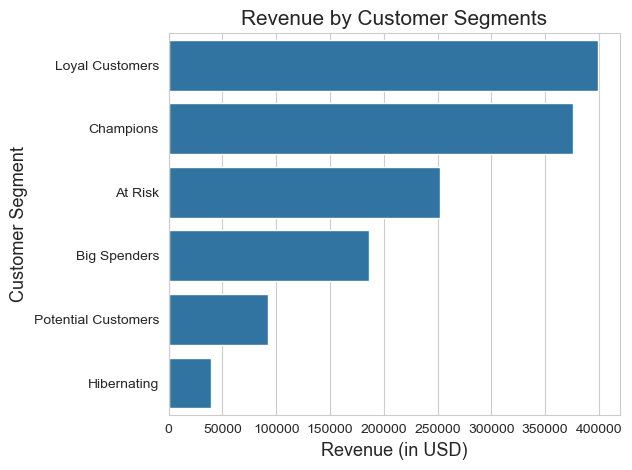

In [111]:
# Visualize the Segments by Monetary value :
sns.barplot(revenue_by_segment,y= 'Segment',x ='Revenue',orient='h')
plt.title("Revenue by Customer Segments",fontsize = 15)
plt.xlabel("Revenue (in USD)",fontsize=13)
plt.ylabel("Customer Segment",fontsize=13)
plt.tight_layout()

In [ ]:
""" 
It shows that 'Loyal Customers' segment provides the highest revenue of above 400k(USD) 
,second best is 'Champions' customer segment with above 350k(USD)
and third is "At Risk" Customers with 250k(USD) revenue.
"""

### Recommendations:

## 1. Improve Campaign Effectiveness:
1. Expand Campaign 3 for Potential Customers—it's working very well and also because they are our biggest customer base.
2. Focus on Campaign 4 and 5 for the Champions segment ,they respond well to them and also because they are second highest contributor to total revenue.
3. Revamp or Replace Campaign 2 due to low engagement across all customer segments.
4. Strengthen Campaign 4 & 5 for Loyal Customers, they are the highest contributor to revenue.
5. Maintain Campaign 5 for Big Spenders, they repond well to that.
6. Re-engage Hibernating Customers with new strategies.
7. Improve At Risk segment responses, especially with Campaign 4 and 5, they are third highest contributor to total revenue.

### 2. Retain Key Customer Segments:
1. Loyal Customers: Offer loyalty rewards to keep them engaged.
2. At-Risk Customers: Send personalized offers to re-engage them before they churn.

In [113]:
# Finished !